In [1]:
import pandas as pd
import pandas_gbq
from google.cloud import bigquery
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

print("SIA Wevengers 분석 환경 준비 완료")

SIA Wevengers 분석 환경 준비 완료


In [2]:
# 1. 고위험군 CAMEO 코드 리스트
target_cameo_codes = [
    '150', '151', '152', '153', '154', '155', 
    '190', '191', '192', '193', '194', '195', '196', 
    '200', '201', '202', '203', '204'
]
formatted_codes = ", ".join([f"'{code}'" for code in target_cameo_codes])

query = f"""
SELECT 
    SQLDATE, 
    EventCode,
    GoldsteinScale, 
    NumMentions, 
    AvgTone,
    ActionGeo_Type,
    ActionGeo_Lat, 
    ActionGeo_Long, 
    SOURCEURL
FROM `gdelt-bq.full.events`
WHERE SQLDATE >= 20130401 
  AND (
    (Actor1CountryCode = 'CHN' AND Actor2CountryCode = 'TWN') OR 
    (Actor1CountryCode = 'TWN' AND Actor2CountryCode = 'CHN')
  )
  AND EventCode IN ({formatted_codes})
  AND IsRootEvent = 1                 -- 핵심 사건만 필터링
  AND ActionGeo_Type IN (3, 4, 5)
"""

project_id = "project-fe69a478-943f-4a4a-bc6" # 로그인창 연결됨
df = pandas_gbq.read_gbq(query, project_id=project_id)

# 결과 확인
print(f"2013년부터 2026년 현재까지 총 {len(df)}건의 데이터를 불러왔습니다.(필터링 적용 O)")
display(df.head())

Downloading: 100%|██████████|
2013년부터 2026년 현재까지 총 11900건의 데이터를 불러왔습니다.(필터링 적용 O)


,SQLDATE,EventCode,GoldsteinScale,NumMentions,AvgTone,ActionGeo_Type,ActionGeo_Lat,ActionGeo_Long,SOURCEURL
0,20160910,190,-10.0,3,-4.699739,5,41.0000,123.000,http://www.bangkokpost.com/news/asia/1082960/t...
1,20160910,190,-10.0,4,-4.699739,5,41.0000,123.000,http://www.bangkokpost.com/news/asia/1082960/t...
2,20160702,194,-10.0,10,-5.000000,4,15.0000,115.000,http://www.miragenews.com/man-killed-after-tai...
3,20160702,194,-10.0,30,-3.785108,4,39.9289,116.388,http://www.newsnow.in/news/taiwan-mistakenly-f...
4,20160702,150,-7.2,64,-4.290429,4,39.9289,116.388,http://www.shanghainews.net/index.php/sid/2454...


In [3]:
# SQLDATE 변환
df['SQLDATE'] = pd.to_datetime(df['SQLDATE'].astype(str), format='%Y%m%d')

In [9]:
# 날짜별 NumMentions 합계
all_dates = pd.date_range(start=df['SQLDATE'].min(), end=df['SQLDATE'].max())

ts_data = (
    df.groupby('SQLDATE')['NumMentions']
      .sum()
      .reindex(all_dates, fill_value=0)
      .to_frame(name='daily_mentions')
)

In [10]:
# 이동평균 계산
ts_data['MA7'] = ts_data['daily_mentions'].rolling(window=7, min_periods=1).mean()
ts_data['MA14'] = ts_data['daily_mentions'].rolling(window=14, min_periods=1).mean()
ts_data['MA30'] = ts_data['daily_mentions'].rolling(window=30, min_periods=1).mean()

In [ ]:
# 전날까지의 이동평균 계산
# ts_data['MA7'] = ts_data['daily_mentions'].rolling(window=7, min_periods=1).mean().shift(1)
# ts_data['MA14'] = ts_data['daily_mentions'].rolling(window=14, min_periods=1).mean().shift(1)
# ts_data['MA30'] = ts_data['daily_mentions'].rolling(window=30, min_periods=1).mean().shift(1)

In [13]:
# 이상탐지 기준 적용
ts_data['is_anomaly_day'] = (
    (ts_data['daily_mentions'] > ts_data['MA7']) &
    (ts_data['daily_mentions'] > ts_data['MA14']) &
    (ts_data['daily_mentions'] > ts_data['MA30']) &
    (ts_data['daily_mentions'] >= 127)
)
"""
개별 이벤트의 numMentions가 127이상..이라면..
anomaly_events = df[
    (df['SQLDATE'].isin(anomaly_dates)) &
    (df['NumMentions'] >= 127)
].copy()
"""

"\n개별 이벤트의 numMentions가 127이상..이라면..\nanomaly_events = df[\n    (df['SQLDATE'].isin(anomaly_dates)) &\n    (df['NumMentions'] >= 127)\n].copy()\n"

In [14]:
# 이상탐지 날짜만 추출
anomaly_dates = ts_data[ts_data['is_anomaly_day']].index

print(f"이상탐지 날짜 수: {len(anomaly_dates)}")
display(ts_data[ts_data['is_anomaly_day']].head())

이상탐지 날짜 수: 201


,daily_mentions,MA7,MA14,MA30,is_anomaly_day
2014-03-20,232,37.714286,22.785714,11.900000,True
2014-05-15,489,72.142857,36.214286,20.366667,True
2014-05-16,312,116.714286,58.500000,30.100000,True
2014-05-17,140,136.714286,68.500000,34.766667,True
2014-07-24,153,27.428571,14.714286,9.500000,True


In [16]:
# anomaly event 추출
anomaly_events = df[
    (df['SQLDATE'].isin(anomaly_dates)) &
    (df['NumMentions'] >= 127)
].copy()

# 날짜별 기사량/이동평균 정보 붙이기
anomaly_events = anomaly_events.merge(
    ts_data[['daily_mentions', 'MA7', 'MA14', 'MA30']],
    left_on='SQLDATE',
    right_index=True,
    how='left'
)

# 중요도 높은 순으로 정렬
anomaly_events = anomaly_events.sort_values(
    by=['daily_mentions', 'NumMentions'],
    ascending=False
)

print(f"이상탐지 기준 적용 후 이벤트 수: {len(anomaly_events)}")
display(anomaly_events.head())

이상탐지 기준 적용 후 이벤트 수: 142


,SQLDATE,EventCode,GoldsteinScale,NumMentions,AvgTone,ActionGeo_Type,ActionGeo_Lat,ActionGeo_Long,SOURCEURL,daily_mentions,MA7,MA14,MA30
988,2022-08-04,194,-10.0,700,-4.222615,4,28.7925,117.262,https://wflapanamacity.iheart.com/content/2022...,4595,1327.571429,692.0,330.933333
1061,2022-08-04,194,-10.0,536,-4.772964,4,24.0000,119.000,https://www.wkms.org/npr-news/npr-news/2022-08...,4595,1327.571429,692.0,330.933333
1075,2022-08-04,150,-7.2,378,-2.070194,4,39.9289,116.388,https://www.stuff.co.nz/world/asia/300654066/c...,4595,1327.571429,692.0,330.933333
999,2022-08-04,194,-10.0,300,-4.222615,4,32.9500,116.642,https://wflapanamacity.iheart.com/content/2022...,4595,1327.571429,692.0,330.933333
1093,2022-08-04,194,-10.0,281,-3.074827,4,25.0478,121.532,https://www.bbc.com/news/live/world-asia-62404233,4595,1327.571429,692.0,330.933333


In [27]:
anomaly_events.head(50)

,SQLDATE,EventCode,GoldsteinScale,NumMentions,AvgTone,ActionGeo_Type,ActionGeo_Lat,ActionGeo_Long,SOURCEURL,daily_mentions,MA7,MA14,MA30
988,2022-08-04,194,-10.0,700,-4.222615,4,28.7925,117.262,https://wflapanamacity.iheart.com/content/2022...,4595,1327.571429,692.000000,330.933333
1061,2022-08-04,194,-10.0,536,-4.772964,4,24.0000,119.000,https://www.wkms.org/npr-news/npr-news/2022-08...,4595,1327.571429,692.000000,330.933333
1075,2022-08-04,150,-7.2,378,-2.070194,4,39.9289,116.388,https://www.stuff.co.nz/world/asia/300654066/c...,4595,1327.571429,692.000000,330.933333
999,2022-08-04,194,-10.0,300,-4.222615,4,32.9500,116.642,https://wflapanamacity.iheart.com/content/2022...,4595,1327.571429,692.000000,330.933333
1093,2022-08-04,194,-10.0,281,-3.074827,4,25.0478,121.532,https://www.bbc.com/news/live/world-asia-62404233,4595,1327.571429,692.000000,330.933333
1077,2022-08-04,194,-10.0,265,-3.880930,4,39.9289,116.388,https://inlandnewstoday.com/story.php?s=68209,4595,1327.571429,692.000000,330.933333
1007,2022-08-04,194,-10.0,159,-3.681634,4,39.9289,116.388,https://www.investmentwatchblog.com/china-has-...,4595,1327.571429,692.000000,330.933333
1076,2022-08-04,150,-7.2,130,-2.139968,4,39.9289,116.388,https://inlandnewstoday.com/story.php?s=68209,4595,1327.571429,692.000000,330.933333
903,2022-08-07,190,-10.0,1420,-4.161978,4,39.9289,116.388,https://www.sfgate.com/news/article/China-keep...,2849,1912.428571,1110.785714,527.233333
892,2022-08-07,190,-10.0,583,-4.175011,4,25.0478,121.532,https://www.gazetteseries.co.uk/news/national/...,2849,1912.428571,1110.785714,527.233333


In [ ]:
# 저장
# anomaly_events.to_csv("anomaly_events_phase3.csv", index=False, encoding="utf-8-sig")

### 이벤트 중요도 스코어링

In [18]:
# CAMEO code
event_counts = (
    anomaly_events['EventCode']
    .value_counts()
    .reset_index()
)

event_counts.columns = ['EventCode', 'count']

display(event_counts)

,EventCode,count
0,190,51
1,150,39
2,194,19
3,192,17
4,193,8
5,151,3
6,195,2
7,154,2
8,152,1


In [31]:
event_counts['EventCode'].value_counts()

EventCode
190    1
150    1
194    1
192    1
193    1
151    1
195    1
154    1
152    1
Name: count, dtype: int64

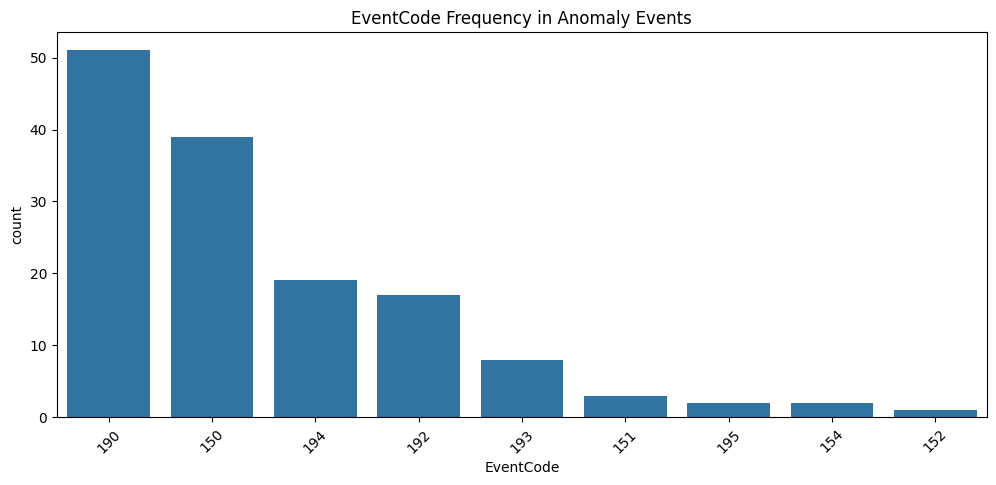

In [19]:
plt.figure(figsize=(12,5))

sns.barplot(
    data=event_counts,
    x='EventCode',
    y='count'
)

plt.title('EventCode Frequency in Anomaly Events')
plt.xticks(rotation=45)
plt.show()

- 190: 일반적 전투/무력 충돌
    - 가장 많은 기사량을 차지함 -> 190계열 event Type score는 높아야 함
- 150: 군사적 태세
- 194: 군사 충돌 (중형 화기 및 전차 교전)
- 192: 영토 점령
- 193: 무력 사용 (소형 화기 교전)

- 실제 갈등/충돌 계열 이벤트로 구성됨. 굿.

In [20]:
# event code 별 기사량 분석
event_mentions = (
    anomaly_events.groupby('EventCode')['NumMentions']
    .agg(['count', 'mean', 'median', 'max'])
    .reset_index()
    .sort_values(by='mean', ascending=False)
)

display(event_mentions)

,EventCode,count,mean,median,max
1,151,3,581.333333,360.0,1190
6,193,8,405.0,247.0,1026
5,192,17,357.823529,290.0,1052
0,150,39,330.128205,188.0,1468
7,194,19,322.0,248.0,700
4,190,51,306.411765,198.0,1420
8,195,2,300.5,300.5,463
3,154,2,182.5,182.5,210
2,152,1,154.0,154.0,154


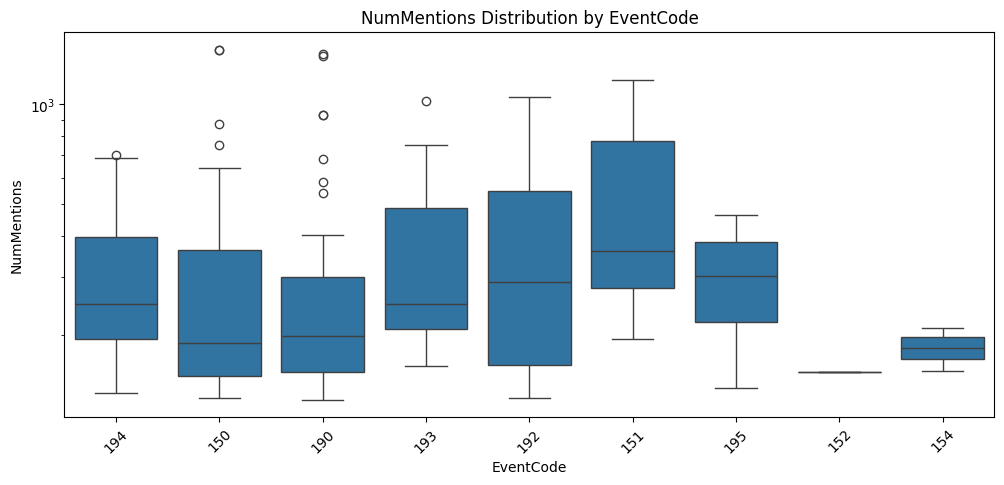

In [21]:
plt.figure(figsize=(12,5))

sns.boxplot(
    data=anomaly_events,
    x='EventCode',
    y='NumMentions'
)

plt.yscale('log')

plt.title('NumMentions Distribution by EventCode')
plt.xticks(rotation=45)
plt.show()

- 151, 192, 193/ ..: 기사량 중앙값 자체가 높다.
- 151: 위에서 봤을 때, 기사량 빈도는 낮은데, 기사량이 매우 크다.
    - 151: 경계수준강화 (군사적 경계 강화, 군사 대비 태세 강화, 동원 준비 등..)
    - 실제 군사 행동 이전 단계이기에-> 발생빈도는 적지만, 발생하면 굉장히 큰 이슈이기에.
    - 151은 실제 행동 이전의 위험 신호로 해석 가능.
    - -> 실제 군사 이동, 장비, 훈련 준비 등 행동으로 이어질 가능성이 높음 -> 위성으로 확인할 가치 높음!!

#### How?
CAMEO 코드를 분석하여

희소성 + 파급력 + 군사 의미를 담을 수 있도록 점수를 매겨야 한다.

- 이미 다 알려진 충돌
- 충돌 직전의 이상 징후

##### CAMEO Code를 그룹별로 분류해서 score를 매기면 괜찮지 않을까..?!!
- 그룹 1: 이미 발생한 군사 충돌 (190~196, 200~204)
- 그룹 2: 군사 행동 이전 단계의 전조 신호 (151, 152, 153)
- 그룹 3: 지속적 긴장 상태 (150, *154, 155*)
    - 그룹 2와 3을 합칠지 고민.


### Event Type Score
- 위에서 정리한 그룹 기반으로 score 매기기
    - -> 하지만, 이 방식은 도메인기반으로 너무 휴리스틱함!! 
    - 정량적 근거가 필요함.

In [ ]:
event_spike = (
    anomaly_events.groupby('EventCode')
    .agg(
        mean_mentions=('NumMentions', 'mean'),
        max_mentions=('NumMentions', 'max'),
        median_mentions=('NumMentions', 'median')
    )
)

event_spike['spike_ratio'] = (
    event_spike['max_mentions'] / event_spike['median_mentions']
)

display(event_spike)

,mean_mentions,max_mentions,median_mentions,spike_ratio
EventCode,,,,
150,330.128205,1468,188.0,7.808511
151,581.333333,1190,360.0,3.305556
152,154.0,154,154.0,1.0
154,182.5,210,182.5,1.150685
190,306.411765,1420,198.0,7.171717
192,357.823529,1052,290.0,3.627586
193,405.0,1026,247.0,4.153846
194,322.0,700,248.0,2.822581
195,300.5,463,300.5,1.540765


- 151(경계 수준 강황): mean 매우 큼, 발생 시 언론의 집중도 매우 높음.
    - spike_ratio 는 상대적으로 낮음
    - -> 이벤트가 터질 때, 급격히 튀는 이벤트라기보다는 발생 자체가 큰 의미의 이벤트
    - 발생 자체가 중요한 이벤트 코드이다.
- 150, 190: spike_ratio 매우 큼.
    - -> 평소 대비 급증 성격의 이벤트.
    - 반면에 151은 spike 민감도보다는 절대적인?임팩트가 큰 이벤트임

- 이를 통해 중요한 이벤트는 크게 두 종류라는 것을 알 수 있음.
    - 평소 대비 급격히 증가하는 이벤트
    - 발생 자체가 큰 영향력인, 이벤트

### Strategic Event Score만 사용하기 (밑의 risk score 빼고..)
Strategic Event Score = spike_ratio + neagative_tone + (domain prior)
- (scale 맞춘 후, 가중치 합으로 계산 필요.)
- spike_ratio : 평시 대비 얼마나 비정상적으로 튀는가(이벤트 코드별 비교)
    - 계산한 spike_ratio(7.8 등..) 값을 MinMax scaling
        - 데이터 기반으로 설명 가능함.
- negative_tone: 현재 사건 긴장도 반영.
    - 단순 avgTone이 아니라, tone 편차 사용!!
    1. event code별 평균 tone계산,
    2. 각 이벤트 편차 계산
    3. 음수일수록 더 위험한, 중요한 이벤트임 => - 씌우기. (음수일수록 점수 증가하도록.)
    4. normalize 하기.
- domain_prior: 군사적 의미, 도메인 조사 결과 - 위성 관측 우선 사건 bonus? 점수 부여
    - 도메인별 점수 부여는 추가할지 말지 고민 필요...
    - 너무 휴리스틱하게 부여하면, 편향될수도 있고..객관적이지 않게 되니깐..
    - 실제 충돌 사건 -> 90점 부여
    - 충돌 전 징후 -> 80~90 점 부여
    - 지속적 긴장 -> 60점 부여

그리고 risk score를 따로 둘 필요가 굳이 있을까...라는 질문이 생김
- 개인적으로는 위 socre구조를 사용한다면, 빼는 것이 맞다고 본다!!

### 최종 score
예) Priority Score = 0.3 × Volume Score + 0.3 × Strategic Event Score + 0.15 ×  Geo Importance
- volume score = 양(quantity)
- Strategic Event Score = 질(quality)
- Geo Importance

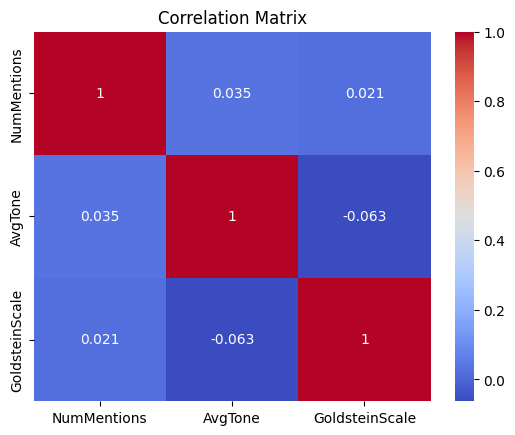

In [40]:
# correlation
corr_cols = [
    'NumMentions',
    'AvgTone',
    'GoldsteinScale'
]

corr = anomaly_events[corr_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Matrix')
plt.show()

- 기사량과 논조, 골든스테인스케일 : 상관관계 없음.
- 기사량이 큰 이벤트 =/ 분위기가 위험한 이벤트

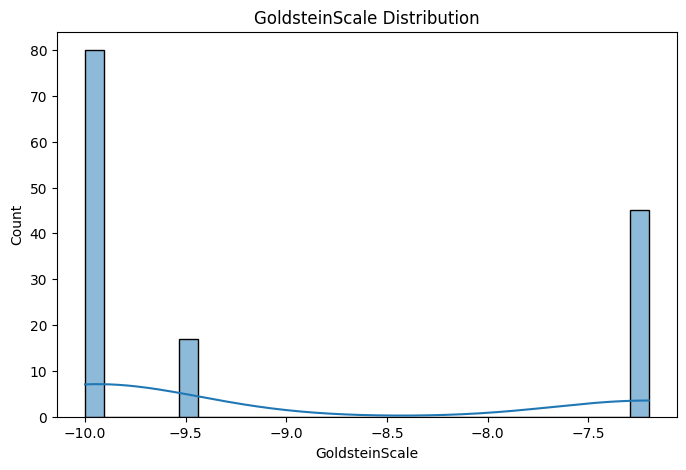

In [22]:
# GoldsteinScale
plt.figure(figsize=(8,5))

sns.histplot(
    anomaly_events['GoldsteinScale'],
    bins=30,
    kde=True
)

plt.title('GoldsteinScale Distribution')
plt.show()

- 아무래도 CAMEO code별로 거의 고정된 값이라, main으로 쓰기엔 무리가 있을 것 같다.
- CAMEO code 와 정보가 중복되기 때문에, 의미가 없다.
- 거의 분별력이 없음.
- 쓴다면,
    - Risk 보조 점수로 사용하기. (Risk 점수는 avgTone + Goldstein ..)
    - 0.2 또는 0.3 정도의 가중치?

In [23]:
anomaly_events['GoldsteinScale'].describe()

count    142.000000
mean      -9.052817
std        1.276225
min      -10.000000
25%      -10.000000
50%      -10.000000
75%       -7.200000
max       -7.200000
Name: GoldsteinScale, dtype: float64

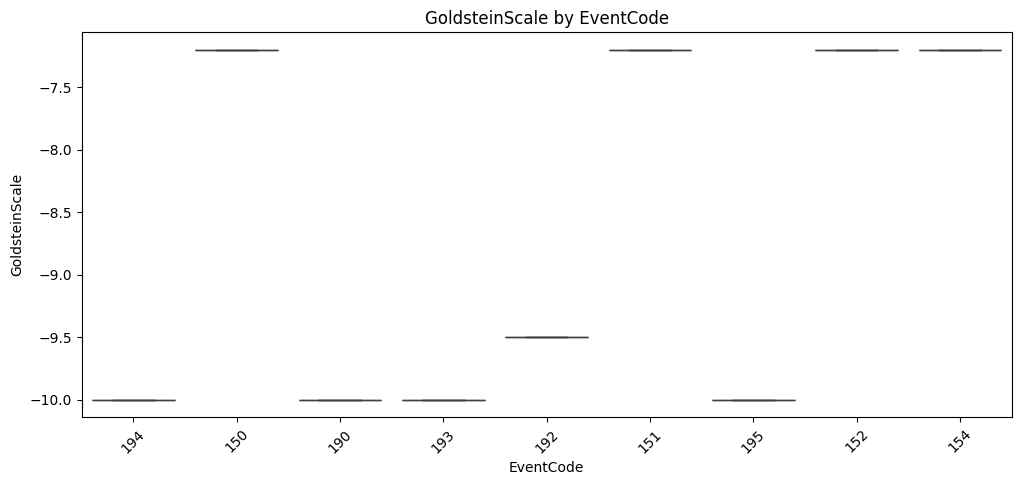

In [24]:
# eventcode별 GoldsteinScale
plt.figure(figsize=(12,5))

sns.boxplot(
    data=anomaly_events,
    x='EventCode',
    y='GoldsteinScale'
)

plt.title('GoldsteinScale by EventCode')
plt.xticks(rotation=45)
plt.show()

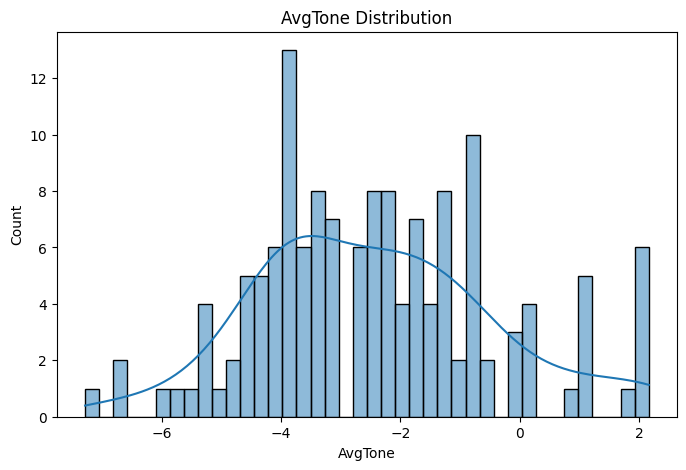

In [25]:
# avgTone 분포
plt.figure(figsize=(8,5))

sns.histplot(
    anomaly_events['AvgTone'],
    bins=40,
    kde=True
)

plt.title('AvgTone Distribution')
plt.show()

- -4 ~ -1 사이에 많이 분포되어 있음ㅁ
    - 군사 이벤트 기사들이 전반적으로 부정적 분위기 라는 뜻.
    - 당연한 결과지만, 의미 있는 결과이다. (goldstein 보다는 분별력 있음 O)

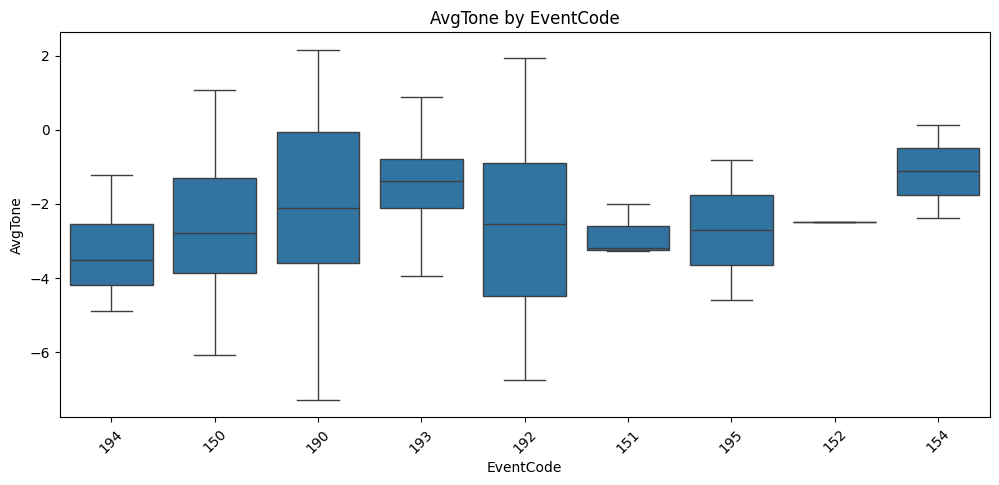

In [26]:
# eventcode별 AvgTone
plt.figure(figsize=(12,5))

sns.boxplot(
    data=anomaly_events,
    x='EventCode',
    y='AvgTone'
)

plt.title('AvgTone by EventCode')
plt.xticks(rotation=45)
plt.show()

In [ ]:
톤이 극단적으로 낮은 애들끼리 리스트를 수집하면 좀 더 유의미한 애들이 나오지 않을까...

- 190, 192(영토점령) : 분산 큼
    - 충돌 이벤트들은 기사 분위기의 분산이 매우 크다.
- 150(군사태세과시), 194(중형 화기 및 전차 교전) ..: 상대적으로 안정적으로... 부정적 분위기
    - 150은 지속적인 긴장 이벤트의 성격
    - 그러면 194는..? -> 분석 더 필요함. 이 상관관계들은 뭐일까..

#### GoldStein VS AvgTone
- Goldstein보다는 avgTone이 실제 기사 분위기 반영을 더 잘한다.
- 현재 상황의 긴장감.. 을 반영이 가능하지 않을까.

#### AvgTone을 사용한다면? How??
AvgTone 편차 기반 점수
- 단순 Tone 값을 사용하는 것보다 *평소보다 얼마나 더 negative한가..*의 의미가 들어가기에.
- 즉, 190 코드는 원래 negative 한 성격이다.
    - 하지만, '오늘 190이 평소보다 훨씬 negative하다'
    - -> 진짜 심각한 상황 가능성을 나타냄.

In [28]:
# eventcode별 평균 Tone계산
event_tone_mean = (
    anomaly_events.groupby('EventCode')['AvgTone']
    .mean()
)

In [29]:
# 편차 계산
anomaly_events['tone_deviation'] = (
    anomaly_events['AvgTone']
    -
    anomaly_events['EventCode'].map(event_tone_mean)
)

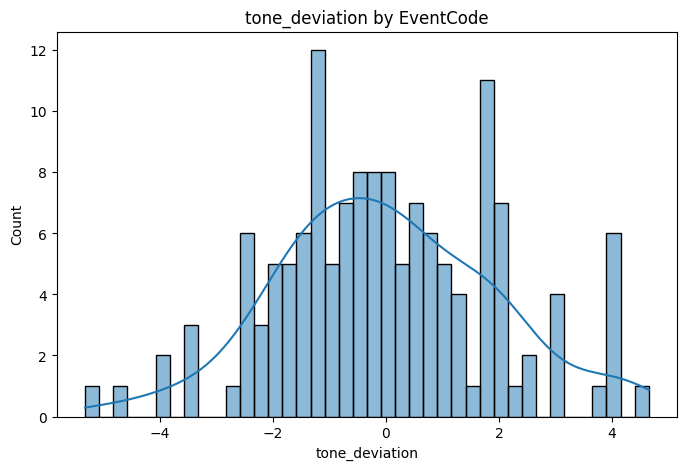

In [30]:
plt.figure(figsize=(8,5))

sns.histplot(
    anomaly_events['tone_deviation'],
    bins=40,
    kde=True
)

plt.title('tone_deviation by EventCode')
plt.show()

In [33]:
event_tone = (
    anomaly_events.groupby('EventCode')
    ['AvgTone']
    .agg(['mean', 'std', 'min'])
)

display(event_tone)

,mean,std,min
EventCode,,,
150,-2.637282,1.607138,-6.098107
151,-2.827893,0.721284,-3.279477
152,-2.500244,NaN,-2.500244
154,-1.127637,1.778240,-2.385042
190,-1.964967,2.424762,-7.288650
192,-2.726153,2.244211,-6.767179
193,-1.527334,1.737819,-3.964070
194,-3.336232,1.056688,-4.908292
195,-2.709821,2.682063,-4.606326


### Risk Sentiment Score
- 예) 0.7 × ToneDeviationRisk + 0.3 × GoldsteinRisk

## 실제 검증